In [29]:
import duckdb
import os
import pandas
import matplotlib.pyplot as plt


In [8]:
os.chdir("..")

In [9]:
con = duckdb.connect("uk_car_analyser.duckdb")

# Cylinder Capacity Analysis
Categorizes vehicles by engine size (displacement) and counts both total tests and unique vehicles per category.
**Key Insight:** Shows the dominance of 1-2L engines in the MOT dataset.

In [17]:
con.execute("""
    SELECT 
        CASE 
            WHEN cylinder_capacity IS NULL THEN 'NULL (EV)'
            WHEN cylinder_capacity < 1000 THEN '< 1000cc'
            WHEN cylinder_capacity < 2000 THEN '1000-1999cc'
            WHEN cylinder_capacity < 4000 THEN '2000-3999cc'
            WHEN cylinder_capacity < 6000 THEN '4000-5999cc'
            ELSE '6000cc+'
        END as displacement,
        COUNT(*) as count,
        COUNT(DISTINCT vehicle_id) AS unique_cars
    FROM read_parquet('data/mot_data_combined.parquet')
    GROUP BY displacement
    ORDER BY displacement
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,displacement,count,unique_cars
0,1000-1999cc,420850330,43474135
1,2000-3999cc,88101580,8728512
2,4000-5999cc,3601483,338929
3,6000cc+,236630,27154
4,< 1000cc,32478528,4627489
5,NULL (EV),1882696,687458


# Mileage Distribution Analysis
Bins vehicles into mileage ranges (e.g., 0-1k, 1-10k, etc.) to understand the age/usage profile of the fleet.
**Note:** Includes a check for negative mileage values.

In [18]:
con.execute("""
    SELECT 
        CASE 
            WHEN test_mileage < 0 THEN 'negative'
            WHEN test_mileage < 1000 THEN '0-1k'
            WHEN test_mileage < 10000 THEN '1-10k'
            WHEN test_mileage < 50000 THEN '10-50k'
            WHEN test_mileage < 100000 THEN '50-100k'
            ELSE '100k+'
        END as mileage,
        COUNT(*) as count,
    FROM read_parquet('data/mot_data_combined.parquet')
    GROUP BY mileage
    ORDER BY mileage
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,mileage,count
0,0-1k,654739
1,1-10k,8752411
2,10-50k,188275201
3,100k+,124158163
4,50-100k,225310733


# Annual Test Volume
Count the total number of MOT tests performed each year from 2005 to 2025.
**Observations:** 
- Highlights the massive volume of data in recent years (2023-2025).
- Spurious low volume data in years **2005, 2013, 2021 and 2022**
- 2005 may be because it was the start of the data collection system, but the other years remain suspicious.

In [20]:
con.execute("""
    SELECT EXTRACT(YEAR FROM test_date) AS year, COUNT(*) AS count
    FROM read_parquet('data/mot_data_combined.parquet')
    GROUP BY year
    ORDER BY year
""").df()

,year,count
0,2005,2359390
1,2006,12553522
2,2007,16020565
3,2008,19172141
4,2009,22319724
5,2010,25233495
6,2011,27697696
7,2012,29454399
8,2013,9354623
9,2014,32340469


# Annual Pass Rates

Calculates the percentage of Pass ('P', 'PRS'), Fail ('F', 'ABA'), and Abort ('ABR') results for each year.
**Logic:**
- **Pass:** 'P' or 'PRS' (Pass or fail then pass in short window - issue was sufficiently minor that it could be fixed quickly)
- **Fail:** 'F' or 'ABA' (Fail or abort due to unsafe conditions)
- **Abort:** 'ABR' (Equipment failure)
- **Other:** Any unexpected codes (should be near zero).


In [25]:
pass_rate=con.execute("""
    SELECT 
        EXTRACT(YEAR FROM test_date) as year,
        
        COUNT(*) FILTER (WHERE test_result IN ('P', 'PRS')) as pass_count,
        COUNT(*) FILTER (WHERE test_result IN ('F', 'ABA')) as fail_count,
        COUNT(*) FILTER (WHERE test_result = 'ABR') as abort_count,
        

        COUNT(*) FILTER (WHERE test_result NOT IN ('P', 'PRS', 'F', 'ABA', 'ABR')) as other_count,
        

        COUNT(*) as total_tests,
        

        100.0 * COUNT(*) FILTER (WHERE test_result IN ('P', 'PRS')) / COUNT(*) as pass_rate,
        100.0 * COUNT(*) FILTER (WHERE test_result IN ('F', 'ABA')) / COUNT(*) as fail_rate
        
        

    FROM read_parquet('data/mot_data_combined.parquet')

    
    GROUP BY year
    ORDER BY year
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

# Visualization: Pass vs Fail Rates
Visualise the Pass and Fail rates over time to identify trends in vehicle reliability or testing standards.

In [27]:
pass_rate

,year,pass_count,fail_count,abort_count,other_count,total_tests,pass_rate,fail_rate
0,2005,2017744,341646,0,0,2359390,85.519732,14.480268
1,2006,10680433,1873089,0,0,12553522,85.079175,14.920825
2,2007,13326996,2693567,2,0,16020565,83.186804,16.813184
3,2008,15677558,3494583,0,0,19172141,81.772599,18.227401
4,2009,17858783,4460941,0,0,22319724,80.013458,19.986542
5,2010,20022101,5211394,0,0,25233495,79.347316,20.652684
6,2011,21767885,5929811,0,0,27697696,78.590959,21.409041
7,2012,23002716,6451682,1,0,29454399,78.096029,21.903968
8,2013,7303694,2050926,3,0,9354623,78.075771,21.924197
9,2014,25137029,7203438,2,0,32340469,77.726235,22.273759


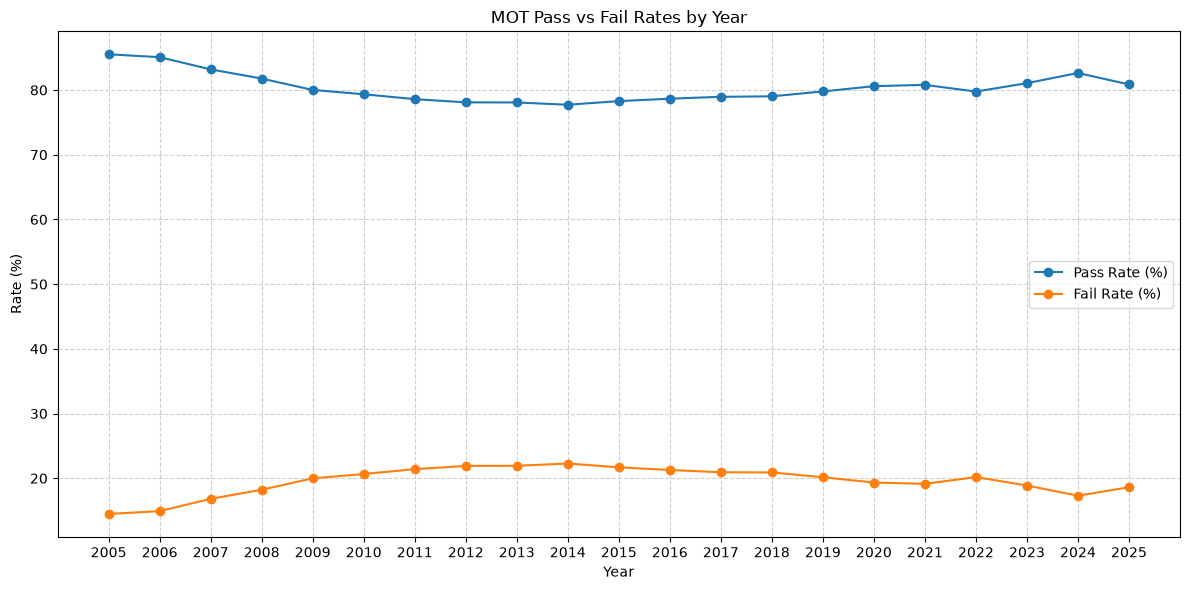

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(pass_rate['year'], pass_rate['pass_rate'], marker='o', label='Pass Rate (%)')
plt.plot(pass_rate['year'], pass_rate['fail_rate'], marker='o', label='Fail Rate (%)')

plt.title('MOT Pass vs Fail Rates by Year')
plt.xlabel('Year')
plt.ylabel('Rate (%)')
plt.xticks(pass_rate['year'])
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

# Pass Rates by Manufacturer

Group by manufacturer instead of year and output pass rates this way.
**Key Findings**: 
- The data is extremely messy, with duplicated `make` (with/without a dash in the name), *DVSA* as a make and other issues.
- We can't draw conclusions from test result summary tables (below) without **Survival Analysis**; Mclaren is known to have issues yet they have the highest pass rate when filtering for more than 10,000 tests - note the low median mileage across tests. 


In [38]:
pass_rate_by_make=con.execute("""
    SELECT * FROM(
    SELECT 
        make,
        MEDIAN(test_mileage) AS median_mileage,
        
        COUNT(*) FILTER (WHERE test_result IN ('P', 'PRS')) as pass_count,
        COUNT(*) FILTER (WHERE test_result IN ('F', 'ABA')) as fail_count,
        COUNT(*) FILTER (WHERE test_result = 'ABR') as abort_count,
        

        COUNT(*) FILTER (WHERE test_result NOT IN ('P', 'PRS', 'F', 'ABA', 'ABR')) as other_count,
        

        COUNT(*) as total_tests,
        

        100.0 * COUNT(*) FILTER (WHERE test_result IN ('P', 'PRS')) / COUNT(*) as pass_rate,
        100.0 * COUNT(*) FILTER (WHERE test_result IN ('F', 'ABA')) / COUNT(*) as fail_rate
        
        

    FROM read_parquet('data/mot_data_combined.parquet')

    
    GROUP BY make
    ORDER BY make
    ) WHERE total_tests>=10000
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [39]:
pass_rate_by_make.sort_values('pass_rate', ascending=False).head(n=10)

,make,median_mileage,pass_count,fail_count,abort_count,other_count,total_tests,pass_rate,fail_rate
56,MCLAREN,12389.5,19891,573,26,0,20490,97.076623,2.796486
45,LAMBORGHINI,17286.5,28900,1151,39,0,30090,96.045198,3.825191
75,ROLLS ROYCE,23855.0,31550,1285,30,0,32865,95.998783,3.909935
48,LEVC,69474.0,57839,2519,94,0,60452,95.677562,4.166942
91,VICTORY,10229.0,12344,566,10,0,12920,95.541796,4.380805
32,HARLEY-DAVIDSON,9845.0,325546,15547,181,0,341274,95.391386,4.555577
31,HARLEY DAVIDSON,10648.0,193827,9592,116,0,203535,95.230304,4.712703
44,KTM,12388.0,86557,4764,59,0,91380,94.722040,5.213395
64,MOTO GUZZI,12446.0,31267,1778,14,0,33059,94.579388,5.378263
26,FERRARI,14316.0,120669,6861,95,0,127625,94.549657,5.375906


In [40]:
pass_rate_by_make.sort_values('pass_rate', ascending=True).head(n=10)

,make,median_mileage,pass_count,fail_count,abort_count,other_count,total_tests,pass_rate,fail_rate
85,TATA,48202.5,11737,6218,1,0,17956,65.365337,34.629093
47,LDV,73946.0,563264,232982,460,0,796706,70.699104,29.243159
39,IVECO,107729.0,635969,249800,1137,0,886906,71.706472,28.165330
69,PIAGGIO,32756.0,11367,4045,27,0,15439,73.625235,26.199883
73,RENAULT,64176.0,20655825,7357835,17250,1,28030911,73.689453,26.249004
66,OPEL,81718.0,67371,23378,34,0,90783,74.211031,25.751517
13,CHRYSLER,70763.0,698732,240177,502,0,939411,74.379798,25.566765
19,DAEWOO,51655.0,428062,146391,105,0,574558,74.502835,25.478890
72,PROTON,46145.5,179442,60236,74,0,239752,74.844840,25.124295
22,DODGE,65448.0,98550,32653,144,0,131347,75.030263,24.860103
